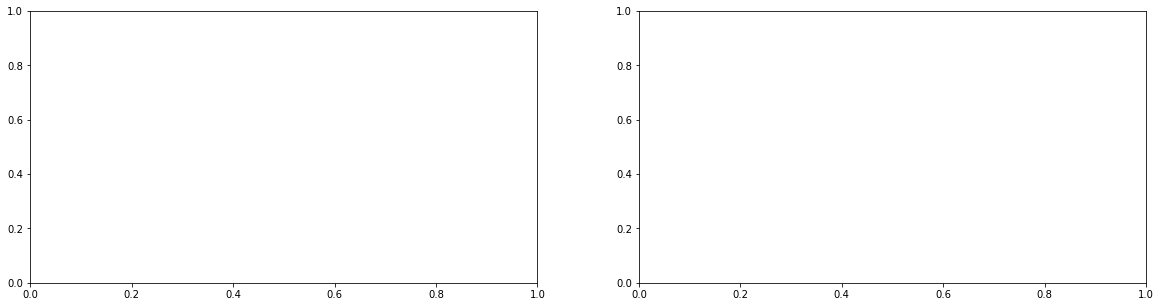

In [1]:
import os
import sys
import time
import copy
sys.path.append('..')

import numpy as np
import math
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

import json

# device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
device = 'cpu'

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 2, figsize=(20,5.0))

### Compute unigram

In [3]:
%%time

vocab_size = 8192
split = 'train'
path = '../SLM/datasets/tinystories/'
filename = f'tinystories.BPE{vocab_size}.{split}.npy'

corpus = np.load(path+filename)
corpus_len = len(corpus)
# corpus = torch.tensor(corpus).to(device)
print(f"corpus has length={corpus_len} and dtype={corpus.dtype}")

corpus has length=529209187 and dtype=int32
CPU times: user 1.99 ms, sys: 309 ms, total: 311 ms
Wall time: 310 ms


In [ ]:
%%time
counts = np.bincount(corpus, minlength=vocab_size)
unigram = counts.astype(np.float64, copy=False)
unigram /= corpus_len

# some checks

# print(counts.sum())
# print(counts.dtype)
# print(len(counts), vocab_size)
# print(counts.max(), counts.min())
# print(unigram.sum())

np.save(f"tinystories/unigram_tinystories.BPE8192.{split}.npy", unigram)

## Plot sorted unigram (Zipf's law?)

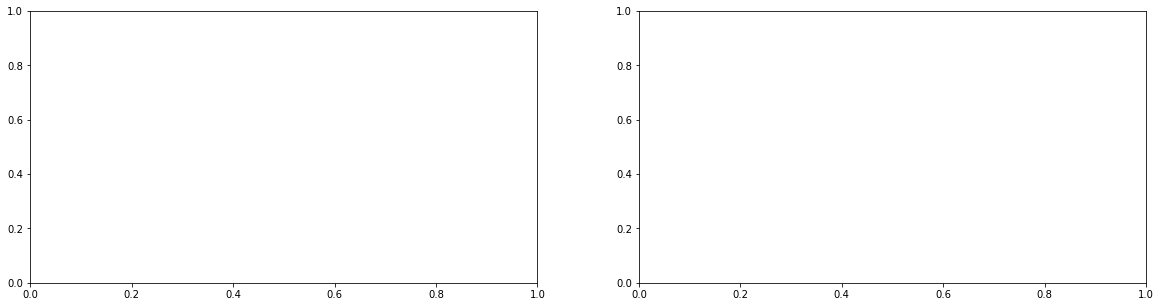

In [9]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 2, figsize=(20,5.0))

8192 1.0000000000000002


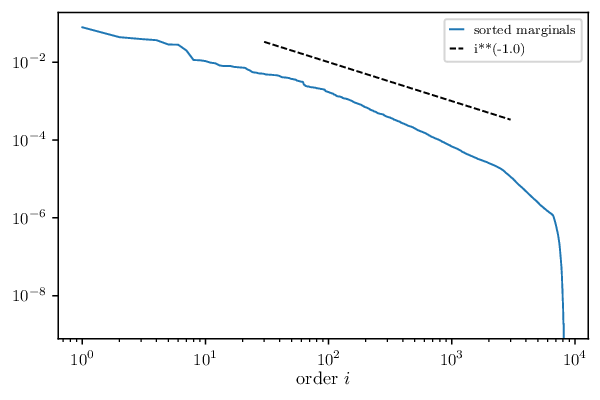

In [10]:
dataset = 'tinystories'
vocab_size = 8192
split = 'train'

# unigram = torch.load(f"{dataset}/unigram_{dataset}.BPE{vocab_size}.{split}.pt")
unigram = np.load(f"{dataset}/unigram_{dataset}.BPE{vocab_size}.{split}.npy")
print(unigram.size, unigram.sum())

matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig, ax = plt.subplots(1, 1, figsize=(1.5*3.8, 1.5*2.4), dpi=120)

unigram_sorted = -np.sort(-unigram)
ax.plot( 1+torch.arange(vocab_size), unigram_sorted, f'C0', label=fr'sorted marginals')

# old unigram, computed on gpu
# old = torch.load(f"{dataset}/unigram_{dataset}.BPE{vocab_size}.{split}_old.pt")
# old_sorted, _ = torch.sort(old, descending=True)
# ax.plot( 1+torch.arange(vocab_size), old_sorted, f'C1', linestyle='dashed', label=fr'old')

zipf = 1.
ax.plot([3e1, 3e3], [3e1**(-zipf), 3e3**(-zipf)], 'k--', label=f'i**(-{zipf})')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'unigram $\pi_i$', fontsize=11)
ax.set_xlabel(r'order $i$', fontsize=11)
ax.legend( fontsize=8, handlelength=1)

## Compute covariance from pairs of independent samples ~ unigram

In [2]:
dataset = 'tinystories'
vocab_size = 8192
split = 'train'

# unigram = torch.load(f"{dataset}/unigram_{dataset}.BPE{vocab_size}.{split}.pt")
unigram = np.load(f"{dataset}/unigram_{dataset}.BPE{vocab_size}.{split}.npy")
unigram = torch.from_numpy(unigram)
print(unigram.size(), unigram.sum())

torch.Size([8192]) tensor(1., dtype=torch.float64)


In [3]:
batch_size = 2**15
num_data = 2**28
num_batches = num_data // batch_size
print(batch_size, num_data)

# NOTE: here counting in int64 which is safer for large integer values, can also
# do in float32 (see a few blocks down)
cov = torch.zeros((vocab_size, vocab_size), device=device, dtype=torch.int64)
prob_right = torch.zeros((vocab_size), device=device, dtype=torch.int64)
prob_left = torch.zeros((vocab_size), device=device, dtype=torch.int64)
ckpt = 1

32768 268435456


In [4]:
%%time
for i in range(num_batches):

    sample1 = torch.multinomial(unigram, batch_size, replacement=True)
    sample2 = torch.multinomial(unigram, batch_size, replacement=True)

    prob_right += torch.bincount(sample1, minlength=vocab_size)
    prob_left += torch.bincount(sample2, minlength=vocab_size)

    pair_ids = sample1*vocab_size + sample2
    # NOTE: the reshape is row-first
    cov += torch.bincount(pair_ids, minlength=vocab_size*vocab_size).reshape(vocab_size, vocab_size)

    if (i+1)==ckpt:

        # number of samples so far
        P = ckpt*batch_size

        right = prob_right.to(torch.float32)/P
        left = prob_left.to(torch.float32)/P
        covf = cov.to(torch.float32)/P
        corr = (covf-right[:,None]@left[None,:]).std()
        print(f'saving at {P} data')
        torch.save(
            {'P': P, 'right': right, 'left': left, 'cov': covf, 'corr': corr},
            f"{dataset}/correlations/correlations_{dataset}.BPE{vocab_size}.{split}_independent_P{ckpt*batch_size}.pt"
        )
        ckpt *= 2

saving at 32768 data
saving at 65536 data
saving at 131072 data
saving at 262144 data
saving at 524288 data
saving at 1048576 data
saving at 2097152 data
saving at 4194304 data
saving at 8388608 data
saving at 16777216 data
saving at 33554432 data
saving at 67108864 data
saving at 134217728 data
saving at 268435456 data
CPU times: user 53min 55s, sys: 23min 25s, total: 1h 17min 21s
Wall time: 19min 21s


In [5]:
# %%time
# matplotlib.use("pgf")
# matplotlib.rcParams.update({
#     "pgf.texsystem": "pdflatex",
#     'font.family': 'serif',
#     'text.usetex': True,
#     'pgf.rcfonts': False,
#     'font.size': 10,
#     'lines.markersize': 4,
#     'lines.linewidth': 1.0,
# })
# fig, ax = plt.subplots(1, 3, figsize=(4*3.8, 1.5*2.4), dpi=120)

# A = covf - right[:, None] @ left[None]
# A = A.numpy()

# U, S, Vh = np.linalg.svd(A)
# svals_sorted = -np.sort(-S)
# print(P, svals_sorted[0], (svals_sorted**2).sum()**.5)
    
# ax[0].plot( 1+torch.arange(S.size), svals_sorted, f'C{i}', label=fr'$P={P}$')
# ax[0].set_yscale('log')
# ax[0].set_xscale('log')
# ax[0].legend( fontsize=8, handlelength=1)

### COMPUTE SVD OF EMPIRICAL COVARIANCES

32768 0.0018211369 0.005428910976587946
65536 0.001143839 0.003788204585847854
131072 0.0008716455 0.0027218558350080736
262144 0.00059085427 0.0019011563276335446
524288 0.00041639345 0.001351780823119605
1048576 0.00029937123 0.0009581104753751218
2097152 0.00023339564 0.0006875978180822845
4194304 0.00017255137 0.00048729707254772687
8388608 0.000117831965 0.00034315472289048887
16777216 9.3192546e-05 0.0002452207526220458
33554432 6.386639e-05 0.00017378369727229164
67108864 4.6044028e-05 0.00012187493128330899
134217728 3.2070646e-05 8.616751558581522e-05
268435456 2.0432492e-05 6.077322544694202e-05
[-0.53725041 -0.33205147] [-0.50372234  0.06776775]
CPU times: user 1h 33min 2s, sys: 55.3 s, total: 1h 33min 57s
Wall time: 24min 8s


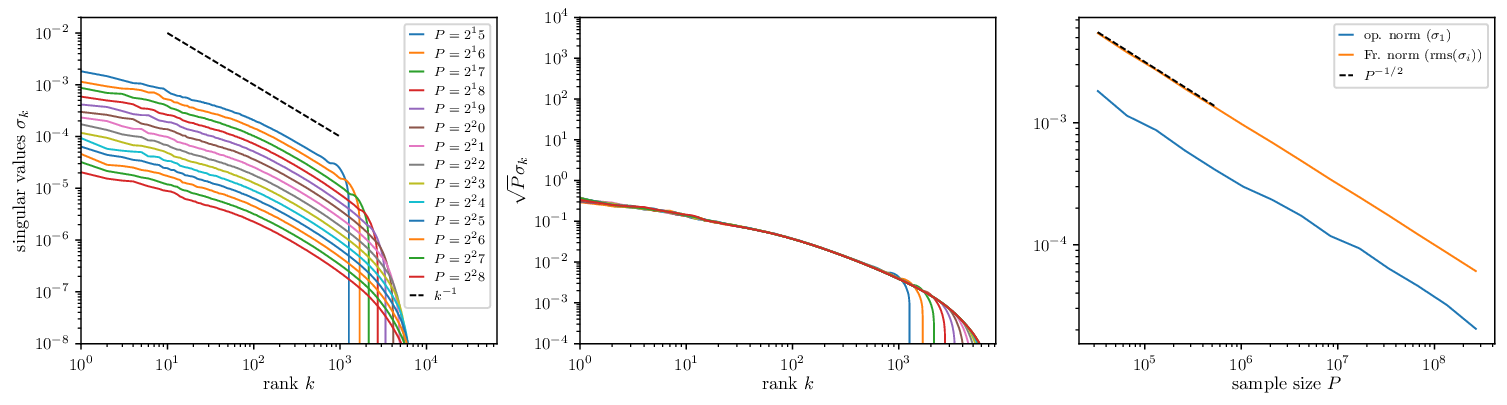

In [6]:
%%time
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig, ax = plt.subplots(1, 3, figsize=(4*3.8, 1.5*2.4), dpi=120)

dataset = 'tinystories'
vocab_size = 8192
split = 'train'

p_list = [ 2**exp for exp in range(15,29)]
onorm_list = []
fnorm_list = []

for i, p in enumerate(p_list):

    stats = torch.load(f"{dataset}/correlations/correlations_{dataset}.BPE{vocab_size}.{split}_independent_P{p}.pt")

    A = stats['cov'] - stats['right'][:, None] @ stats['left'][None]
    A = A.numpy()

    U, S, Vt = np.linalg.svd(A)

    torch.save(
        {'P': p, 'U': torch.from_numpy(U).to(torch.float32), 'S': torch.from_numpy(S).to(torch.float32), 'Vt': torch.from_numpy(Vt).to(torch.float32)},
        f"{dataset}/correlations/CovSVD_tinystories.BPE{vocab_size}.{split}_independent_P{p}.pt"
    )
    
    svals_sorted = -np.sort(-S)
    print(p, svals_sorted[0], (svals_sorted**2).sum()**.5)

    onorm_list.append(svals_sorted[0])
    fnorm_list.append((svals_sorted**2).sum()**.5)

    exponent = int(math.log(p)/math.log(2))
    ax[0].plot( 1+torch.arange(svals_sorted.size), svals_sorted, f'C{i}', label=fr'$P=2^{exponent}$')
    ax[1].plot( 1+torch.arange(svals_sorted.size), svals_sorted*p**.5, f'C{i}', label=fr'$P=2^{{exponent}}$')

gamma = 1.
G = 1e-1
ax[0].plot([1e1, 1e3], [G*1e1**(-gamma), G*1e3**(-gamma)], 'k--', label='$k^{-1}$')

ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].set_ylabel('singular values $\sigma_k$', fontsize=11)
ax[0].set_xlabel('rank $k$', fontsize=11)
ax[0].legend( fontsize=8, handlelength=1, loc='upper right')
ax[0].set_xlim(1,8192*8)
ax[0].set_ylim(1e-8,2e-2)

ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_ylabel('$\sqrt{P}\sigma_k$', fontsize=11)
ax[1].set_xlabel('rank $k$', fontsize=11)
ax[1].set_xlim(1,8192)
ax[1].set_ylim(1e-4,1e4)

ax[2].plot(p_list, onorm_list, f'C0', label='op. norm ($\sigma_1$)')
ax[2].plot(p_list, fnorm_list, f'C1', label='Fr. norm ($\mathrm{rms}(\sigma_i)$)')
ax[2].plot([p for p in p_list[:5]], [p**(-.5) for p in p_list[:5]] , 'k--', label=r'$P^{-1/2}')
fit_f = np.polyfit(np.log(np.array(p_list[-5:])), np.log(np.array(fnorm_list[-5:])), 1)
fit_o = np.polyfit(np.log(np.array(p_list[-5:])), np.log(np.array(onorm_list[-5:])), 1)
print(fit_o, fit_f)
# ax[1].plot(p_list, [o*math.sqrt(vocab_size) for o in onorm_list], f'C2', label='scaled op. norm')
ax[2].set_yscale('log')
ax[2].set_xscale('log')
ax[2].set_xlabel('sample size $P$', fontsize=11)
ax[2].legend( fontsize=8, handlelength=1)

In [7]:
fig.savefig(f"CovSVD_tinystories.BPE{vocab_size}.{split}_independent.pdf")